<a href="https://colab.research.google.com/gist/Chrissydrx/848de0903a85916d99713cdac508d1c6/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import warnings
import kagglehub
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
class MVTecDataLoader:
    """Data loader for MVTec Anomaly Detection Dataset"""

    def __init__(self, img_size=(224, 224), category='bottle'):
        # Download dataset from Kaggle and save to data/
        print("Downloading MVTec dataset from Kaggle...")
        downloaded_path = kagglehub.dataset_download("ipythonx/mvtec-ad")

        # Create data directory if it doesn't exist
        data_dir = Path("data")
        data_dir.mkdir(exist_ok=True)

        # Move the downloaded data to our data/ directory
        import shutil
        final_data_path = data_dir / "mvtec_anomaly_detection"

        # If the final path doesn't exist, copy from download location
        if not final_data_path.exists():
            print(f"Moving dataset from {downloaded_path} to {final_data_path}")
            shutil.copytree(downloaded_path, final_data_path)

        self.data_path = final_data_path
        self.img_size = img_size
        self.category = category
        print(f"Dataset ready at: {self.data_path}")

    def load_images(self, subset='train'):
        """Load images from specified subset (train/test)"""
        images = []
        labels = []

        subset_path = self.data_path / self.category / subset

        # Load normal images
        normal_path = subset_path / 'good'
        if normal_path.exists():
            for img_path in normal_path.glob('*.png'):
                img = self._preprocess_image(img_path)
                if img is not None:
                    images.append(img)
                    labels.append(0)  # 0 for normal

        # Load anomalous images (only in test set)
        if subset == 'test':
            for anomaly_dir in subset_path.iterdir():
                if anomaly_dir.is_dir() and anomaly_dir.name != 'good':
                    for img_path in anomaly_dir.glob('*.png'):
                        img = self._preprocess_image(img_path)
                        if img is not None:
                            images.append(img)
                            labels.append(1)  # 1 for anomaly

        return np.array(images), np.array(labels)

    def _preprocess_image(self, img_path):
        """Preprocess individual image"""
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                return None

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            return img
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None

# Initialize data loader
CATEGORY = 'hazelnut'  # Choose from available categories
IMG_SIZE = (448, 448)

loader = MVTecDataLoader(IMG_SIZE, CATEGORY)

# Load training data (only normal images)
train_images, train_labels = loader.load_images('train')
print(f"Training images shape: {train_images.shape}")
print(f"Training labels distribution: {np.bincount(train_labels)}")

# Load test data (normal + anomalous images)
test_images, test_labels = loader.load_images('test')
print(f"Test images shape: {test_images.shape}")
print(f"Test labels distribution: {np.bincount(test_labels)}")

Dataset ready at: data/mvtec_anomaly_detection
Training images shape: (391, 448, 448, 3)
Training labels distribution: [391]
Test images shape: (110, 448, 448, 3)
Test labels distribution: [40 70]


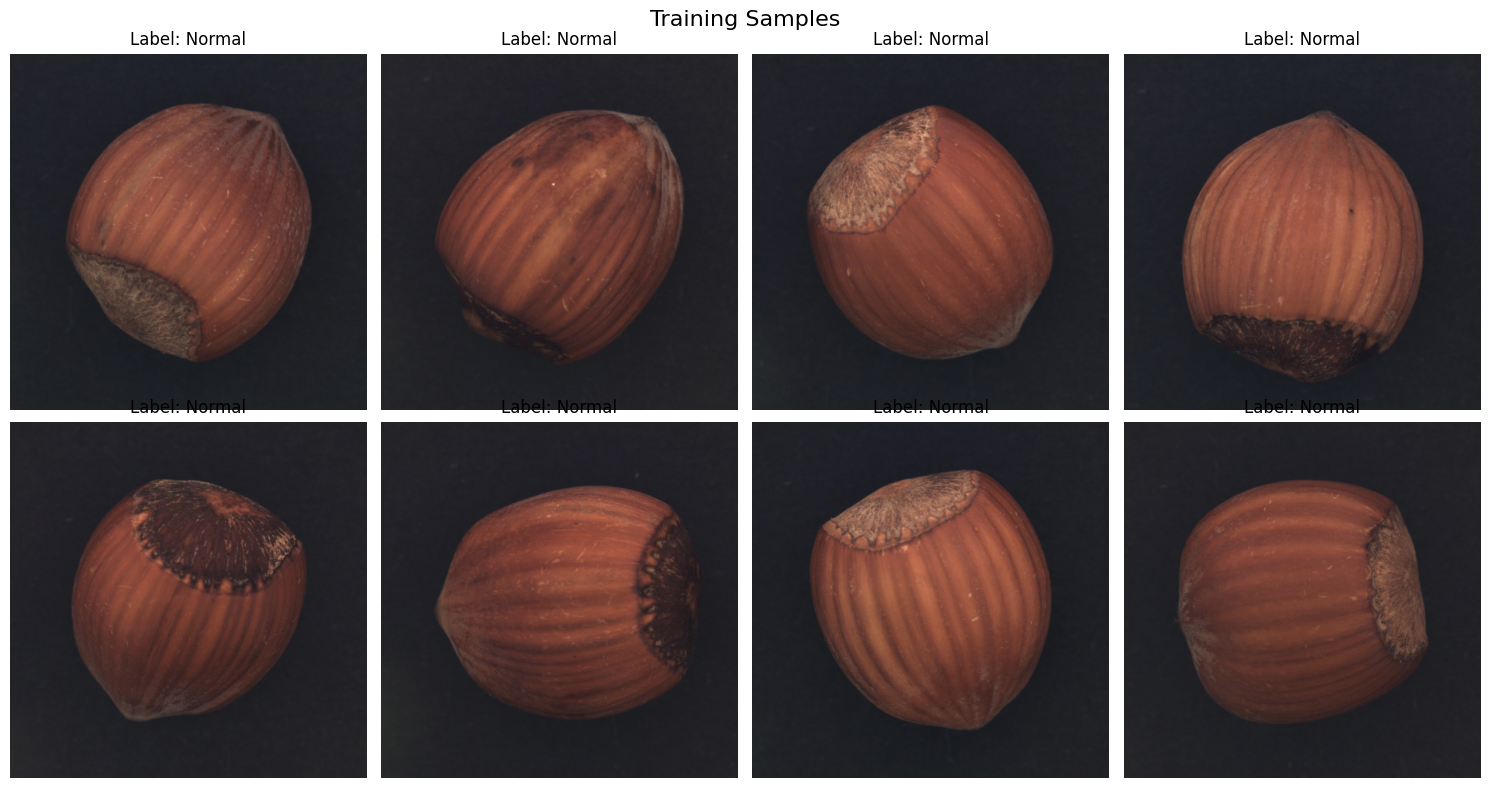

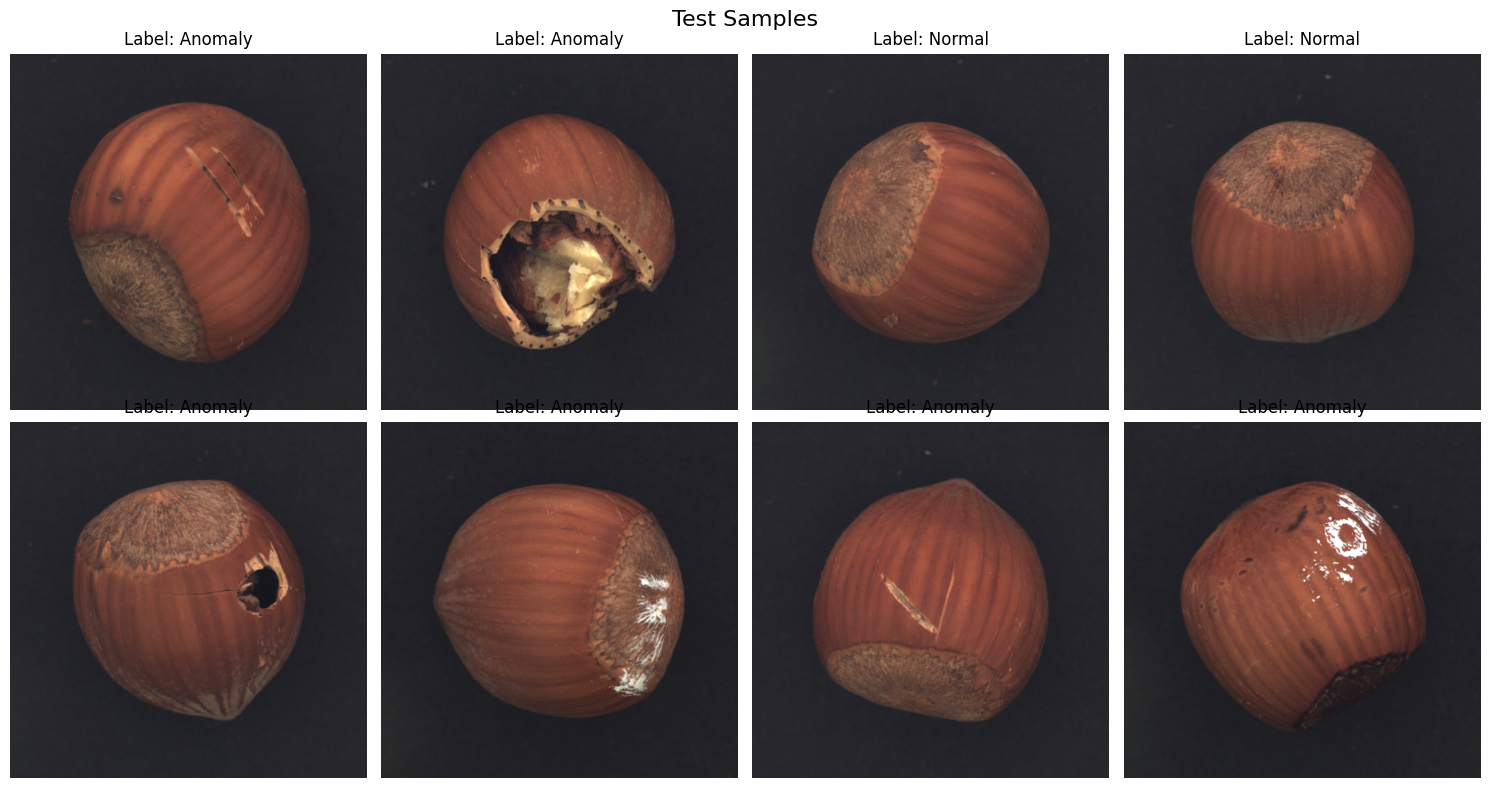

In [3]:
def visualize_samples(images, labels, num_samples=8, title="Samples"):
    """Visualize sample images"""
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    fig.suptitle(title, fontsize=16)

    indices = np.random.choice(len(images), num_samples, replace=False)

    for i, idx in enumerate(indices):
        row, col = i // 4, i % 4
        axes[row, col].imshow(images[idx])
        axes[row, col].set_title(
            f"Label: {'Anomaly' if labels[idx] == 1 else 'Normal'}"
        )
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize training samples
visualize_samples(train_images, train_labels, title="Training Samples")

# Visualize test samples
visualize_samples(test_images, test_labels, title="Test Samples")

In [4]:
class CNNAutoencoder:
    """CNN-based Autoencoder for anomaly detection"""

    def __init__(self, input_shape=(448, 448, 3)):
        self.input_shape = input_shape
        self.model = None

    def build_model(self):
        """Build the autoencoder model"""
        # Encoder
        encoder_input = layers.Input(shape=self.input_shape)

        # Encoder layers
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(
            encoder_input
        )
        x = layers.MaxPooling2D((2, 2), padding='same')(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2), padding='same')(x)

        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2), padding='same')(x)

        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

        # Decoder layers
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(
            encoded
        )
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.UpSampling2D((2, 2))(x)

        # Output layer
        decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

        # Create model
        self.model = Model(encoder_input, decoded)
        return self.model

    def compile_model(self, learning_rate=5e-5):
        """Compile the model"""
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        self.model.compile(
            optimizer=optimizer,
            loss='mse',
            metrics=['mae']
        )

    def get_model_summary(self):
        """Get model summary"""
        return self.model.summary()

# Build and compile the model
autoencoder = CNNAutoencoder(input_shape=(*IMG_SIZE, 3))
model = autoencoder.build_model()
autoencoder.compile_model()

print("Model Architecture:")
autoencoder.get_model_summary()

Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 448, 448, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 448, 448, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 448, 448, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,366,659 (5.21 MB)

 Trainable params: 1,366,659 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='constant'
)

# Split training data into train and validation
train_imgs, val_imgs = train_test_split(
    train_images, test_size=0.2, random_state=42
)

print(f"Training set size: {len(train_imgs)}")
print(f"Validation set size: {len(val_imgs)}")

# Create data generators
batch_size = 16

train_generator = train_datagen.flow(
    train_imgs, train_imgs,  # Input and target are the same for autoencoder
    batch_size=batch_size,
    shuffle=True
)

val_generator = ImageDataGenerator().flow(
    val_imgs, val_imgs,
    batch_size=batch_size,
    shuffle=False
)

Training set size: 312
Validation set size: 79


In [6]:
# Define callbacks
callbacks = [
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.2,                    # More aggressive reduction for complex model
        patience=5,                   # Increased patience for combined loss
        min_lr=1e-8,                   # Lower minimum for fine-tuning
        verbose=1,
        cooldown=2,                    # Longer cooldown for stability
        mode='max'
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,                   # Early stopping for complex model
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ModelCheckpoint(
        f'models/best_enhanced_autoencoder_{CATEGORY}.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,       # Save full model for complex architecture
        verbose=0,
        mode='max'
    )
]

# Training parameters
EPOCHS = 200
STEPS_PER_EPOCH = len(train_imgs) // batch_size
VALIDATION_STEPS = len(val_imgs) // batch_size

In [7]:
# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")


Starting training...
Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - loss: 0.1032 - mae: 0.3070 - val_loss: 0.0880 - val_mae: 0.2771 - learning_rate: 5.0000e-05
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0902 - mae: 0.2823 - val_loss: 0.0857 - val_mae: 0.2721 - learning_rate: 5.0000e-05
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 651ms/step - loss: 0.0750 - mae: 0.2461 - val_loss: 0.0393 - val_mae: 0.1593 - learning_rate: 5.0000e-05
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0409 - mae: 0.1641 - val_loss: 0.0374 - val_mae: 0.1562 - learning_rate: 5.0000e-05
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 648ms/step - loss: 0.0383 - mae: 0.1569 - val_loss: 0.0279 - val_mae: 0.1301 - learning_rate: 5.0000e-05
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0290 - mae: 0.1358 - val_loss: 0.0273 - val_mae: 0.1300 - learning_rate: 5.0000e-05
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 644ms/step - loss: 0.0257 - mae: 0.1263 - val_loss: 0.010

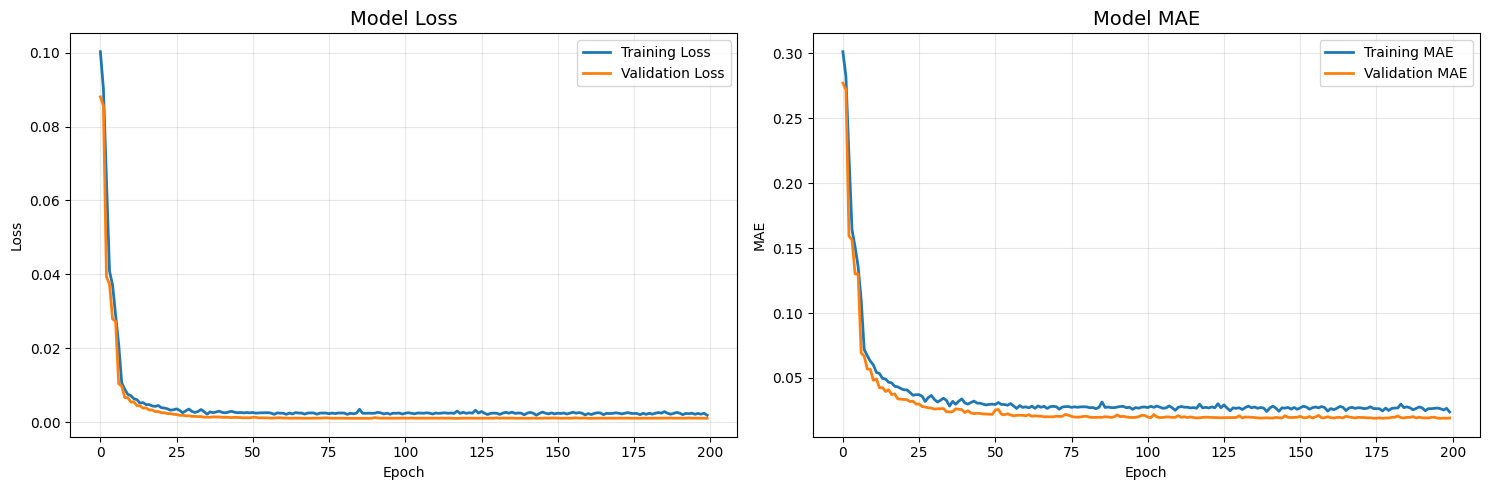

In [13]:
def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot MAE
    ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
    ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    ax2.set_title('Model MAE', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
def calculate_reconstruction_error(model, images):
    """Calculate reconstruction error for images"""
    reconstructed = model.predict(images, verbose=0)
    errors = np.mean(np.square(images - reconstructed), axis=(1, 2, 3))
    return errors

def find_optimal_threshold(reconstruction_errors, test_labels, 
                          metric='recall', target_label=1, num_thresholds=100):
    """
    Find the optimal threshold that maximizes the specified metric for the target label.
    
    Args:
        reconstruction_errors: Array of reconstruction errors
        test_labels: True labels (0 for normal, 1 for anomaly)
        metric: Metric to optimize ('recall', 'precision', 'f1', 'accuracy')
        target_label: Label to optimize for (default: 1 for anomalies)
        num_thresholds: Number of thresholds to test
    
    Returns:
        optimal_threshold: Threshold that maximizes the metric
        best_score: Best score achieved
        threshold_metrics: Dictionary with metrics for different thresholds
    """
    from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
    
    # Get unique reconstruction errors as potential thresholds
    sorted_errors = np.sort(reconstruction_errors)
    
    # Create threshold candidates - use percentiles for efficiency
    threshold_candidates = [
        np.percentile(sorted_errors, p) 
        for p in np.linspace(0, 99.9, num_thresholds)
    ]
    
    best_score = 0
    optimal_threshold = threshold_candidates[0]
    threshold_metrics = []
    
    for threshold in threshold_candidates:
        # Make predictions with current threshold
        predictions = (reconstruction_errors > threshold).astype(int)
        
        # Calculate the specified metric
        if metric == 'recall':
            score = recall_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        elif metric == 'precision':
            score = precision_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        elif metric == 'f1':
            score = f1_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        elif metric == 'accuracy':
            score = accuracy_score(test_labels, predictions)
        else:
            raise ValueError(f"Unsupported metric: {metric}")
        
        # Calculate all metrics for analysis
        recall = recall_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        precision = precision_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        f1 = f1_score(test_labels, predictions, pos_label=target_label, zero_division=0)
        accuracy = accuracy_score(test_labels, predictions)
        
        # Store metrics for analysis
        threshold_metrics.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'accuracy': accuracy,
            'target_score': score,
            'predictions': predictions.copy()
        })
        
        # Update best threshold if score improved
        if score > best_score:
            best_score = score
            optimal_threshold = threshold
    
    return optimal_threshold, best_score, threshold_metrics

def find_optimal_threshold_for_recall(reconstruction_errors, test_labels, target_label=1):
    """
    Find the optimal threshold that maximizes recall for the target label.
    (Backward compatibility wrapper)
    """
    return find_optimal_threshold(reconstruction_errors, test_labels, 
                                 metric='recall', target_label=target_label)

def evaluate_anomaly_detection(model, test_images, test_labels, 
                              optimization_metric=None, target_label=1):
    """
    Evaluate anomaly detection performance with optional metric optimization.
    
    Args:
        model: Trained autoencoder model
        test_images: Test images
        test_labels: Test labels (0 for normal, 1 for anomaly)
        optimization_metric: Metric to optimize ('recall', 'precision', 'f1', 'accuracy', None)
                           If None, uses 95th percentile of normal errors
        target_label: Label to optimize for (default: 1 for anomalies)
    
    Returns:
        Dictionary with evaluation results
    """
    # Calculate reconstruction errors
    reconstruction_errors = calculate_reconstruction_error(model, test_images)

    # Calculate AUC score
    auc_score = roc_auc_score(test_labels, reconstruction_errors)

    # Split errors by label for analysis
    normal_errors = reconstruction_errors[test_labels == 0]
    anomaly_errors = reconstruction_errors[test_labels == 1]

    if optimization_metric is not None:
        # Find optimal threshold for the specified metric
        optimal_threshold, best_score, threshold_metrics = find_optimal_threshold(
            reconstruction_errors, test_labels, 
            metric=optimization_metric, target_label=target_label
        )
        threshold = optimal_threshold
        print(f"Optimal threshold for {optimization_metric}: {threshold:.6f}")
        print(f"Best {optimization_metric} achieved: {best_score:.4f}")
    else:
        # Use original method (95th percentile of normal errors)
        threshold = np.percentile(normal_errors, 95)
        threshold_metrics = None

    # Make final predictions
    predictions = (reconstruction_errors > threshold).astype(int)

    # Calculate final metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    precision = precision_score(test_labels, predictions, zero_division=0)
    recall = recall_score(test_labels, predictions, zero_division=0)
    f1 = f1_score(test_labels, predictions, zero_division=0)
    
    # Calculate recall specifically for each class
    recall_normal = recall_score(test_labels, predictions, pos_label=0, zero_division=0)
    recall_anomaly = recall_score(test_labels, predictions, pos_label=1, zero_division=0)

    return {
        'auc_score': auc_score,
        'threshold': threshold,
        'reconstruction_errors': reconstruction_errors,
        'predictions': predictions,
        'normal_errors': normal_errors,
        'anomaly_errors': anomaly_errors,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'recall_normal': recall_normal,
        'recall_anomaly': recall_anomaly,
        'threshold_metrics': threshold_metrics,
        'optimization_metric': optimization_metric
    }

# Evaluate the model with recall optimization
results = evaluate_anomaly_detection(model, test_images, test_labels, optimization_metric='recall')

print(f"AUC Score: {results['auc_score']:.4f}")
print(f"Optimal Threshold: {results['threshold']:.6f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall (Overall): {results['recall']:.4f}")
print(f"Recall (Normal - Label 0): {results['recall_normal']:.4f}")
print(f"Recall (Anomaly - Label 1): {results['recall_anomaly']:.4f}")
print(f"F1-Score: {results['f1_score']:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, results['predictions']))

# Compare different optimization strategies
print("\n" + "="*70)
print("COMPARISON OF DIFFERENT OPTIMIZATION STRATEGIES")
print("="*70)

# Original method
results_original = evaluate_anomaly_detection(model, test_images, test_labels, optimization_metric=None)
print(f"Original (95th percentile) - Threshold: {results_original['threshold']:.6f}, Recall: {results_original['recall_anomaly']:.4f}")

# Recall optimization
results_recall = evaluate_anomaly_detection(model, test_images, test_labels, optimization_metric='recall')
print(f"Recall optimized - Threshold: {results_recall['threshold']:.6f}, Recall: {results_recall['recall_anomaly']:.4f}")

# Precision optimization
results_precision = evaluate_anomaly_detection(model, test_images, test_labels, optimization_metric='precision')
print(f"Precision optimized - Threshold: {results_precision['threshold']:.6f}, Precision: {results_precision['precision']:.4f}")

# F1 optimization
results_f1 = evaluate_anomaly_detection(model, test_images, test_labels, optimization_metric='f1')
print(f"F1 optimized - Threshold: {results_f1['threshold']:.6f}, F1: {results_f1['f1_score']:.4f}")

print(f"\nRecall improvement (vs original): {(results_recall['recall_anomaly'] - results_original['recall_anomaly']):.4f}")

# Use recall-optimized results for further analysis
results = results_recall

AUC Score: 0.8361
Optimal Threshold: 0.001250

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.95      0.72        40
           1       0.95      0.60      0.74        70

    accuracy                           0.73       110
   macro avg       0.77      0.77      0.73       110
weighted avg       0.82      0.73      0.73       110



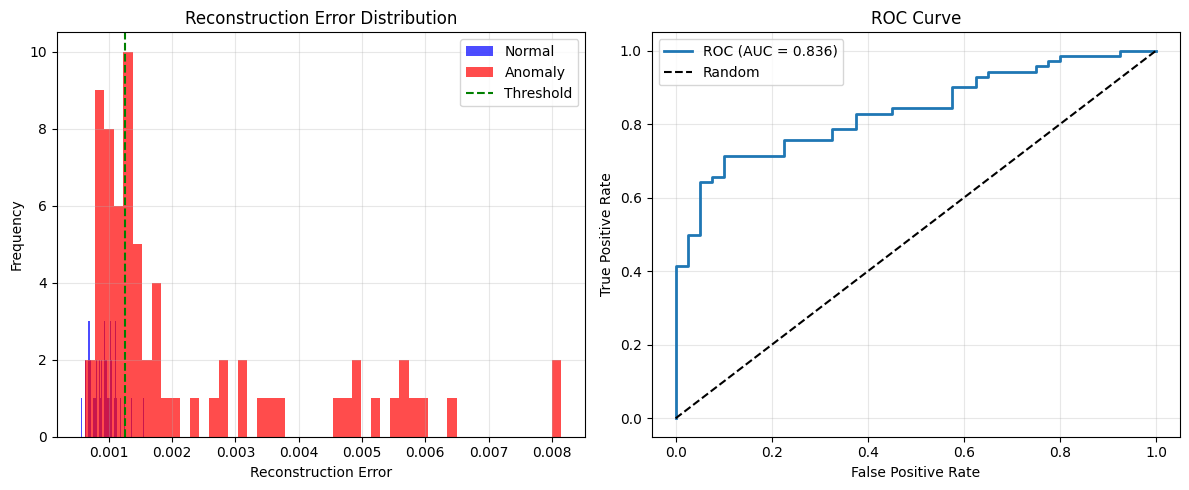

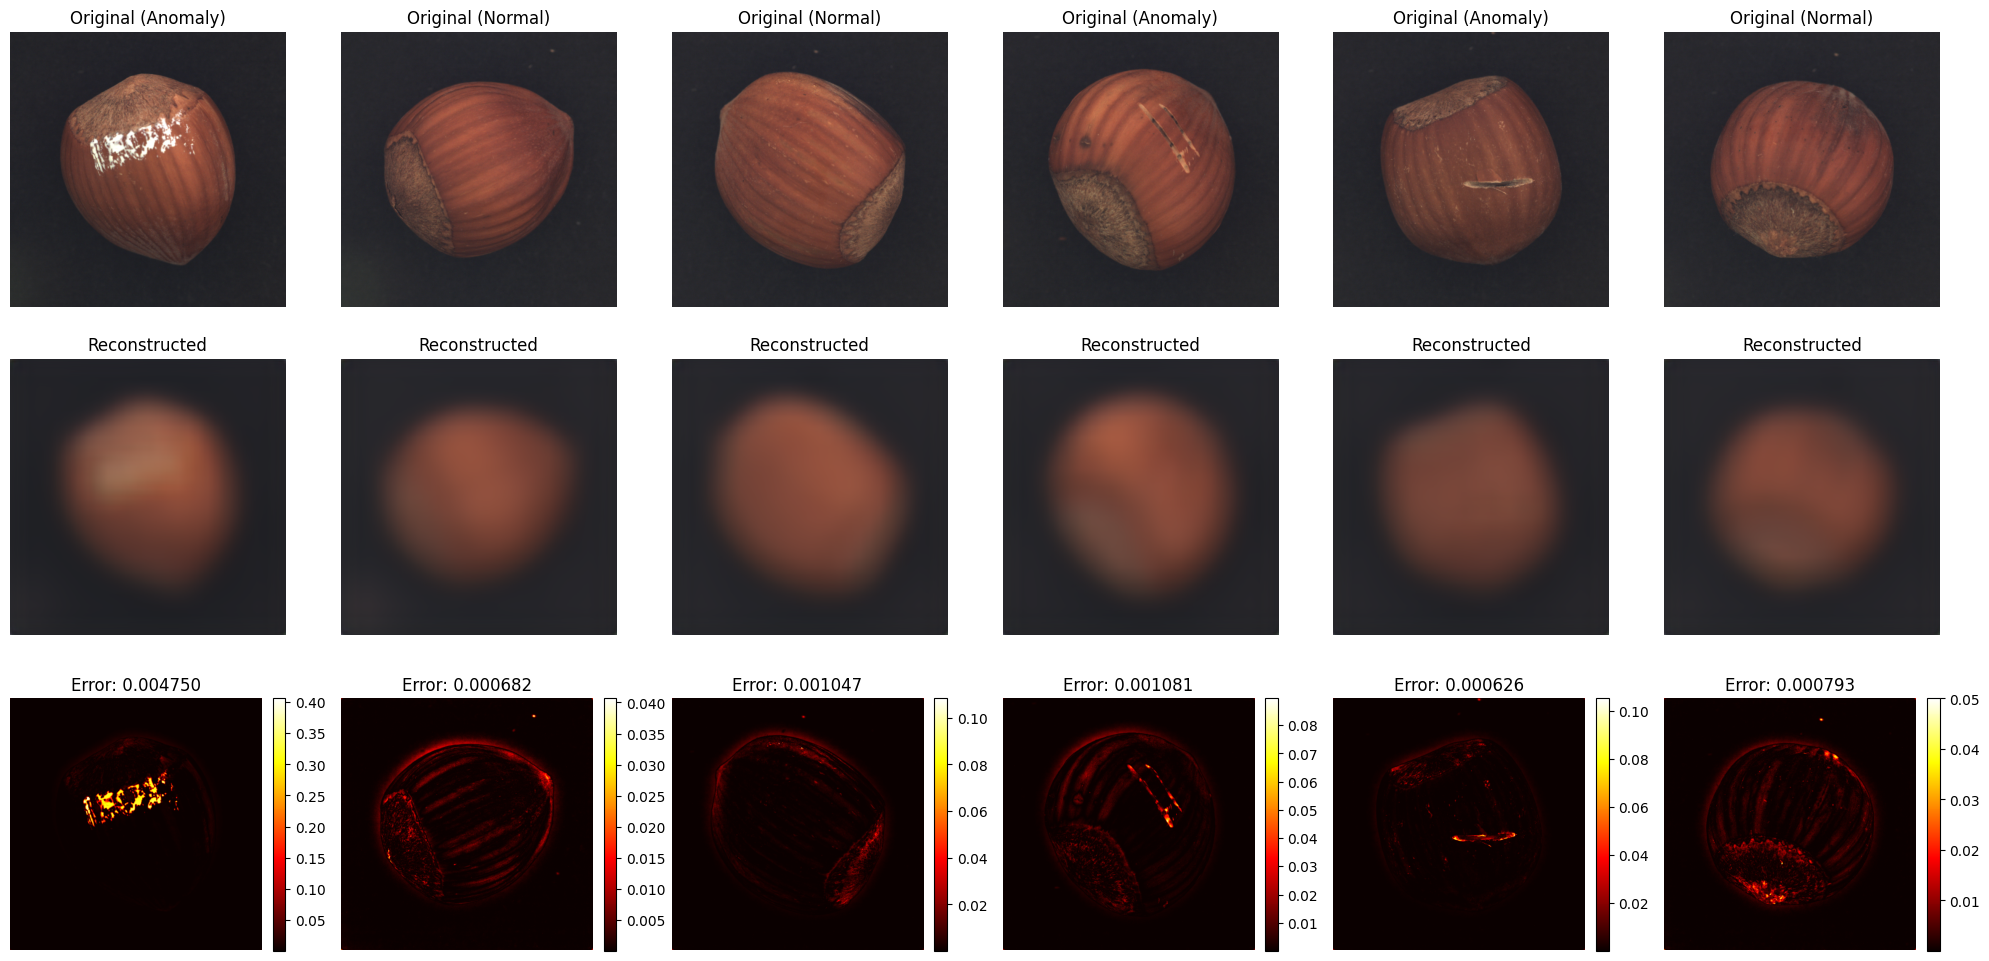

In [ ]:
def plot_threshold_optimization(results):
    """Plot threshold optimization results"""
    if results['threshold_metrics'] is None:
        print("No threshold optimization data available. Run with optimization_metric set")
        return
    
    threshold_metrics = results['threshold_metrics']
    thresholds = [m['threshold'] for m in threshold_metrics]
    
    # Get the metric that was optimized
    optimization_metric = results.get('optimization_metric', 'recall')
    
    if optimization_metric == 'recall':
        target_values = [m['recall'] for m in threshold_metrics]
        optimal_value = results['recall_anomaly']
        ylabel = 'Recall (Label 1)'
        title = 'Recall vs Threshold Optimization'
    elif optimization_metric == 'precision':
        target_values = [m['precision'] for m in threshold_metrics]
        optimal_value = results['precision']
        ylabel = 'Precision (Label 1)'
        title = 'Precision vs Threshold Optimization'
    elif optimization_metric == 'f1':
        target_values = [m['f1'] for m in threshold_metrics]
        optimal_value = results['f1_score']
        ylabel = 'F1-Score (Label 1)'
        title = 'F1-Score vs Threshold Optimization'
    else:
        target_values = [m['recall'] for m in threshold_metrics]
        optimal_value = results['recall_anomaly']
        ylabel = 'Recall (Label 1)'
        title = 'Metric vs Threshold Optimization'
    
    plt.figure(figsize=(15, 5))
    
    # Plot metric vs threshold
    plt.subplot(1, 3, 1)
    plt.plot(thresholds, target_values, linewidth=2, color='blue')
    plt.axvline(results['threshold'], color='red', linestyle='--', 
                label=f'Optimal Threshold: {results["threshold"]:.6f}')
    plt.axhline(optimal_value, color='red', linestyle=':', alpha=0.7,
                label=f'Max {optimization_metric.title()}: {optimal_value:.4f}')
    plt.xlabel('Threshold')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot error distributions with optimal threshold
    plt.subplot(1, 3, 2)
    plt.hist(results['normal_errors'], bins=50, alpha=0.7, label='Normal', color='blue')
    plt.hist(results['anomaly_errors'], bins=50, alpha=0.7, label='Anomaly', color='red')
    plt.axvline(results['threshold'], color='green', linestyle='--', label='Optimal Threshold')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ROC curve visualization
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(test_labels, results['reconstruction_errors'])

    plt.subplot(1, 3, 3)
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {results["auc_score"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_reconstruction_errors(results):
    """Plot reconstruction error distributions"""
    plt.figure(figsize=(12, 5))

    # Plot error distributions
    plt.subplot(1, 2, 1)
    plt.hist(results['normal_errors'], bins=50, alpha=0.7, label='Normal', color='blue')
    plt.hist(results['anomaly_errors'], bins=50, alpha=0.7, label='Anomaly', color='red')
    plt.axvline(results['threshold'], color='green', linestyle='--', label='Threshold')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ROC curve visualization
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(test_labels, results['reconstruction_errors'])

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {results["auc_score"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def visualize_reconstructions(model, images, labels, num_samples=6):
    """Visualize original vs reconstructed images"""
    indices = np.random.choice(len(images), num_samples, replace=False)

    fig, axes = plt.subplots(3, num_samples, figsize=(20, 10))

    reconstructed = model.predict(images[indices], verbose=0)
    errors = calculate_reconstruction_error(model, images[indices])

    for i in range(num_samples):
        # Original image
        axes[0, i].imshow(images[indices[i]])
        axes[0, i].set_title(f"Original ({'Anomaly' if labels[indices[i]] == 1 else 'Normal'})")
        axes[0, i].axis('off')

        # Reconstructed image
        axes[1, i].imshow(reconstructed[i])
        axes[1, i].set_title(f"Reconstructed")
        axes[1, i].axis('off')

        # Error map
        error_map = np.mean(np.square(images[indices[i]] - reconstructed[i]), axis=2)
        im = axes[2, i].imshow(error_map, cmap='hot')
        axes[2, i].set_title(f"Error: {errors[i]:.6f}")
        axes[2, i].axis('off')
        plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Visualize results with threshold optimization
print("Threshold Optimization Results:")
plot_threshold_optimization(results)

print("\nReconstructed Images Comparison:")
visualize_reconstructions(model, test_images, test_labels)

print("\nOriginal Method Results (for comparison):")
plot_reconstruction_errors(results_original)

In [11]:
# Save the final model
from datetime import datetime

model_name = f'mvtec_autoencoder_{CATEGORY}_final_{datetime.now().strftime("%Y%m%d_%H%M%S")}.h5'
model.save(f'models/{model_name}')
print(f"Model saved as 'models/{model_name}'")

# Print final summary
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Dataset Category: {CATEGORY}")
print(f"Image Size: {IMG_SIZE}")
print(f"Training Samples: {len(train_images)}")
print(f"Test Samples: {len(test_images)}")
print(f"AUC Score: {results['auc_score']:.4f}")
print(f"Threshold: {results['threshold']:.6f}")
print("="*50)

Model saved as 'models/mvtec_autoencoder_hazelnut_final_20250803_155515.h5'

FINAL RESULTS SUMMARY
Dataset Category: hazelnut
Image Size: (448, 448)
Training Samples: 391
Test Samples: 110
AUC Score: 0.8361
Threshold: 0.001250


In [ ]:
from sklearn.metrics import recall_score, accuracy_score
import numpy as np

# 1. Get reconstruction errors
def get_reconstruction_errors(model, data):
    reconstructed = model.predict(data)
    errors = np.mean(np.square(data - reconstructed), axis=(1, 2, 3))
    return errors

# 2. Find best threshold for recall
def find_best_threshold_for_recall(model, x_val, y_val):
    errors = get_reconstruction_errors(model, x_val)
    best_threshold = None
    best_recall = 0
    for t in np.linspace(errors.min(), errors.max(), 100):
        y_pred = (errors > t).astype(int)  # 1 = anomaly, 0 = normal
        recall = recall_score(y_val, y_pred)
        if recall > best_recall:
            best_recall = recall
            best_threshold = t
    return best_threshold, best_recall

# Example usage:
threshold, recall = find_best_threshold_for_recall(model, x_val, y_val)
print(f"Best threshold: {threshold}, Recall: {recall}")